Model Performance
------------------------------
MAE : 244.64
RMSE: 825.5
R²  : -0.154


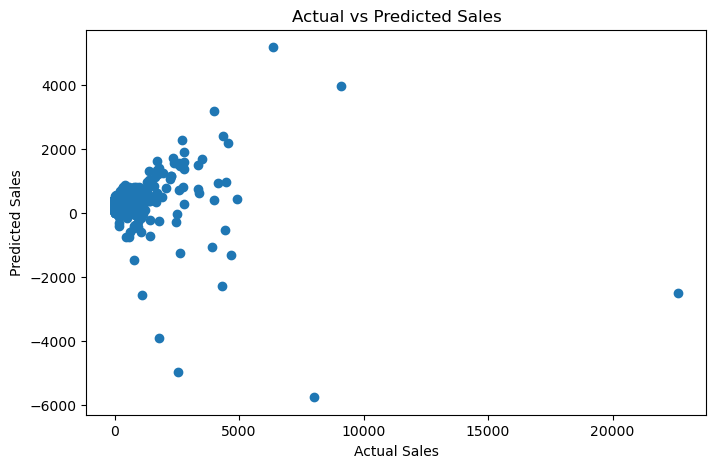


Predicted Sales: 385.46


In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Load Dataset
df = pd.read_csv("Sample - Superstore.csv", encoding="latin1")

# Select useful columns
df = df[['Sales', 'Profit', 'Discount', 'Quantity',
         'Category', 'Region', 'Ship Mode']]

# Handle missing values
df.dropna(inplace=True)

# Encode categorical columns
le = LabelEncoder()

for col in ['Category', 'Region', 'Ship Mode']:
    df[col] = le.fit_transform(df[col])

# Features and Target
X = df.drop('Sales', axis=1)
y = df['Sales']

# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Train Model
model = LinearRegression()
model.fit(X_train, y_train)

# Predictions
y_pred = model.predict(X_test)

# Evaluation
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("Model Performance")
print("-" * 30)
print("MAE :", round(mae, 2))
print("RMSE:", round(rmse, 2))
print("R²  :", round(r2, 3))

# Actual vs Predicted Plot
plt.figure(figsize=(8, 5))
plt.scatter(y_test, y_pred)
plt.xlabel("Actual Sales")
plt.ylabel("Predicted Sales")
plt.title("Actual vs Predicted Sales")
plt.show()

# Future Prediction Example
sample = pd.DataFrame({
    'Profit': [100],
    'Discount': [0.1],
    'Quantity': [5],
    'Category': [0],
    'Region': [1],
    'Ship Mode': [2]
})

prediction = model.predict(sample)

print("\nPredicted Sales:", round(prediction[0], 2))

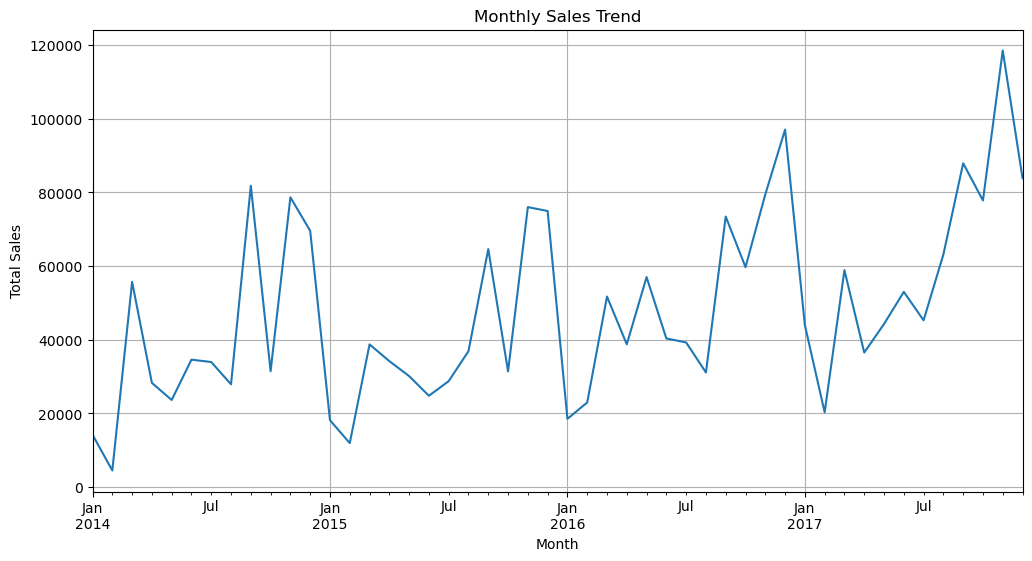

In [9]:
import pandas as pd
import matplotlib.pyplot as plt

# Load dataset
df = pd.read_csv("Sample - Superstore.csv", encoding="latin1")

# Convert Order Date to datetime
df['Order Date'] = pd.to_datetime(df['Order Date'])

# Monthly sales trend
monthly_sales = df.groupby(
    df['Order Date'].dt.to_period('M')
)['Sales'].sum()

# Plot
plt.figure(figsize=(12,6))
monthly_sales.plot()

plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Total Sales")
plt.grid(True)

plt.show()